# Imports

In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Modules
from draw_expr_graph import draw_dot
from value import Value

# Derivative Intuition

## One variable

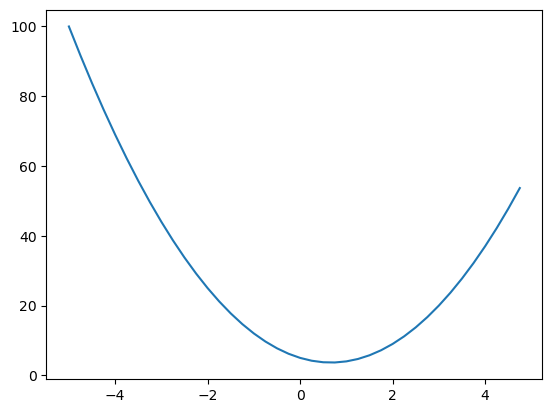

In [19]:
# f(x) = 3x^2 - 4x + 5
def f(x):
    return 3 * (x ** 2) - (4 * x) + 5

xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
plt.show()

In [20]:
# f'(x) = 6x - 4
# f'(x) = lt[h->0] (f(x + h) - f(x))/f(h)
# The derivative tells us how the function behaves (increases/decreases)
# and by how much when x is slightly increased
def print_slope(x, h=0.000001):
    print(f"f'(x) at x = {x}")
    print(f'f(x + h)             : {f(x + h)}')
    print(f'f(x)                 : {f(x)}')
    print(f'(f(x + h) - f(x)) / h: {(f(x + h) - f(x))/h}')
    print()

# At x = 3, if we slightly increase 'x', we see that f(x) increases
# f'(x) theoretically at x = 3 should be 6x - 4 = 6.3 - 4 = 14
print_slope(3)

# At x = -3, if we slightly increase 'x', we see that f(x) decreases
# f'(x) theoretically at x = -3 should be 6x - 4 = -6.3 - 4 = -22
print_slope(-3)

f'(x) at x = 3
f(x + h)             : 20.000014000003002
f(x)                 : 20
(f(x + h) - f(x)) / h: 14.000003002223593

f'(x) at x = -3
f(x + h)             : 43.999978000003
f(x)                 : 44
(f(x + h) - f(x)) / h: -21.999997002808414



In [21]:
# At x = 2/3, if we slightly increase 'x', we see that f(x) approx stays the same
# f'(x) theoretically at x = 2/3 should be 6x - 4 = 6(2/3) - 4 = 0
print_slope(2/3)

f'(x) at x = 0.6666666666666666
f(x + h)             : 3.6666666666696663
f(x)                 : 3.666666666666667
(f(x + h) - f(x)) / h: 2.999378523327323e-06



## Multiple variables

In [22]:
# g = ab + c
def g(a, b, c): return a * b + c
g(2.0, -3.0, 10.0)

4.0

In [23]:
def print_slope_a(a, b, c, h=0.000001):
    print(f"g'(a, b, c) at a = {a}, b = {b}, c = {c}")
    print(f'g(a + h, b, c)             : {g(a + h, b, c)}')
    print(f'g(a, b, c)                 : {g(a, b, c)}')
    print(f'(g(a + h, b, c) - g(a)) / h: {(g(a + h, b, c) - g(a, b, c))/h}')
    print()
    
def print_slope_b(a, b, c, h=0.000001):
    print(f"g'(a, b, c) at a = {a}, b = {b}, c = {c}")
    print(f'g(a, b + h, c)             : {g(a, b + h, c)}')
    print(f'g(a, b, c)                 : {g(a, b, c)}')
    print(f'(g(a, b + h, c) - g(a)) / h: {(g(a, b + h, c) - g(a, b, c))/h}')
    print()
    
def print_slope_c(a, b, c, h=0.000001):
    print(f"g'(a, b, c) at a = {a}, b = {b}, c = {c}")
    print(f'g(a, b, c + h)             : {g(a, b, c + h)}')
    print(f'g(a, b, c)                 : {g(a, b, c)}')
    print(f'(g(a, b, c + h) - g(a)) / h: {(g(a, b, c + h) - g(a, b, c))/h}')
    print()

In [24]:
# Partial derivatives
# ∂g/∂a = b
# ∂g/∂b = a
# ∂g/∂c =  (If c is increased by h, ab + c increases by the same amount h => slope wrt c = 1)
print_slope_a(2.0, -3.0, 10.0) # should be b = -3
print_slope_b(2.0, -3.0, 10.0) # should be a = 2
print_slope_c(2.0, -3.0, 10.0) # should be 1

g'(a, b, c) at a = 2.0, b = -3.0, c = 10.0
g(a + h, b, c)             : 3.9999969999999996
g(a, b, c)                 : 4.0
(g(a + h, b, c) - g(a)) / h: -3.000000000419334

g'(a, b, c) at a = 2.0, b = -3.0, c = 10.0
g(a, b + h, c)             : 4.000002
g(a, b, c)                 : 4.0
(g(a, b + h, c) - g(a)) / h: 2.000000000279556

g'(a, b, c) at a = 2.0, b = -3.0, c = 10.0
g(a, b, c + h)             : 4.000000999999999
g(a, b, c)                 : 4.0
(g(a, b, c + h) - g(a)) / h: 0.9999999992515995



# Value class
- Data structure for holding more complex expressions to be able to find the derivatives
- It not only keeps track of the value, but also what expression (using other Value objects) created this Value object

In [25]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
print(a)
print(b)
print(c)
print(a + b)
print(a * b)

Value(data=2.0, label=a)
Value(data=-3.0, label=b)
Value(data=10.0, label=c)
Value(data=-1.0, label=)
Value(data=-6.0, label=)


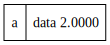

In [26]:
draw_dot(a)

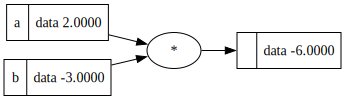

In [27]:
draw_dot(a * b)

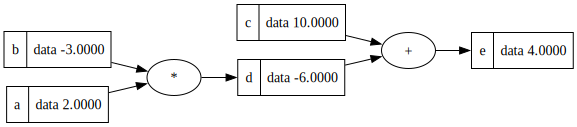

In [28]:
# e = ab + c
d = a * b; d.label = 'd'
e = d + c; e.label = 'e'
draw_dot(e)

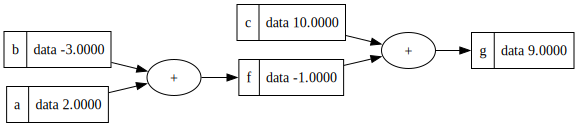

In [29]:
# g = a + b + c
f = a + b; f.label = 'f'
g = f + c; g.label = 'g'
draw_dot(g)

Value(data=-8.0, label=L)


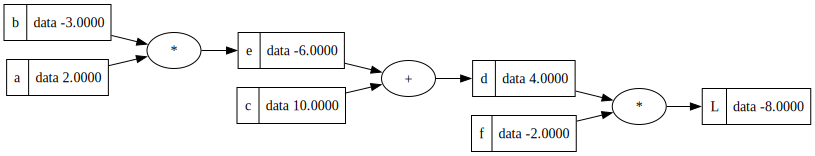

In [30]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')
e = a * b; e.label = 'e' # e = ab
d = e + c; d.label = 'd' # d = e + c = ab + c
f = Value(-2.0, label='f')
L = d * f; L.label = 'L' # L = df = (ab + c)f

# a=2, b=-3, c=10, f=2 => L = (ab + c)f = (-6 + 10)(-2) = -8
print(L)
draw_dot(L)

## Backpropagation intuition

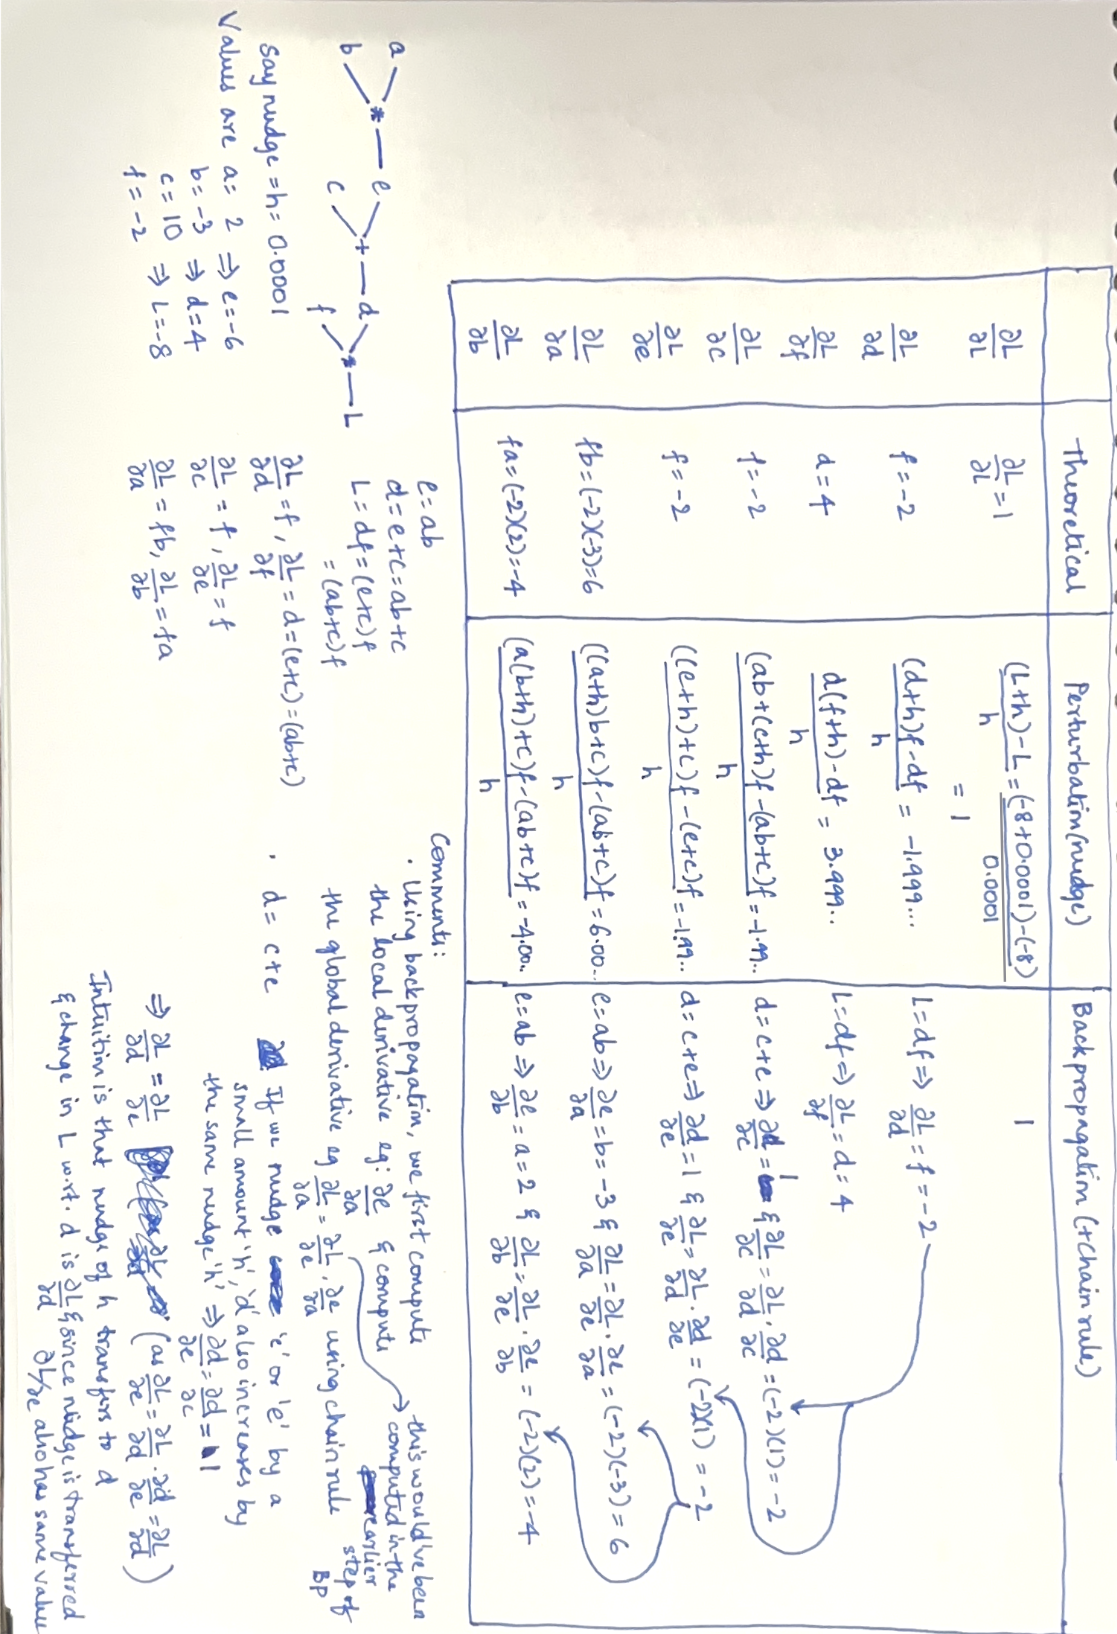

In [31]:
def compute_L(a, b, c, f):
    e = a * b; e.label = 'e' # e = ab
    d = e + c; d.label = 'd' # d = e + c = ab + c
    L = d * f; L.label = 'L' # L = df = (ab + c)f
    return L

In [32]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')

h = 0.0001

# ∂L/∂f
L1 = compute_L(a, b, c, f)
f.data += h
L2 = compute_L(a, b, c, f)
f_grad = (L2.data - L1.data)/h
print(f"∂L/∂f: {f_grad}")
f.data -= h

# ∂L/∂c
L1 = compute_L(a, b, c, f)
c.data += h
L2 = compute_L(a, b, c, f)
c_grad = (L2.data - L1.data)/h
print(f"∂L/∂c: {c_grad}")
c.data -= h

# ∂L/∂a
L1 = compute_L(a, b, c, f)
a.data += h
L2 = compute_L(a, b, c, f)
a_grad = (L2.data - L1.data)/h
print(f"∂L/∂a: {a_grad}")
a.data -= h

# ∂L/∂b
L1 = compute_L(a, b, c, f)
b.data += h
L2 = compute_L(a, b, c, f)
b_grad = (L2.data - L1.data)/h
print(f"∂L/∂b: {b_grad}")
b.data -= h

∂L/∂f: 3.9999999999995595
∂L/∂c: -1.9999999999953388
∂L/∂a: 6.000000000021544
∂L/∂b: -4.000000000008441


## Gradient Descent Intuition
- Gradients
    - $∂L/∂f = 4$ => If f is increased by 1, L increases by 4
    - $∂L/∂c = -2$
    - $∂L/∂a = 6$
    - $∂L/∂b = -4$
- So to increase the value of L overall, we need to nudge all the values of a, b, c, f based on the gradient (both sign and magnitude). If (∂L/∂a) is positive => increasing a will increase L.
  - a = a + (∂L/∂a)(rate)
  - b = b + (∂L/∂b)(rate)
  - c = c + (∂L/∂c)(rate)
  - f = f + (∂L/∂f)(rate)
- To decrease L, we need to do the opposite. We need to nudge the values of a, b, c, f in the opposite sign of the gradient.
  - a = a - (∂L/∂a)(rate)
  - b = b - (∂L/∂b)(rate)
  - c = c - (∂L/∂c)(rate)
  - f = f - (∂L/∂f)(rate)

In [33]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
f = Value(-2.0, label='f')
L = compute_L(a, b, c, f)
print(f"Old L: {L.data}")

# Say learning rate = 0.01
learning_rate = 0.01
a.data = a.data + (learning_rate * a_grad)
b.data = b.data + (learning_rate * b_grad)
c.data = c.data + (learning_rate * c_grad)
f.data = f.data + (learning_rate * f_grad)

# This new L should be higher as we nudged a, b, c, f to increase L
L = compute_L(a, b, c, f)
print(f"New L: {L.data}")

Old L: -8.0
New L: -7.286495999998483
